# Balanced QLoRA: all attention projections, rank 16

Supervised WildFireVQA training using frozen CLIP features, trainable multimodal projectors, and QLoRA adapters. Validation selects the checkpoint; the isolated test split is used only for final generation metrics.


In [1]:
# Install dependencies if running on Kaggle / Colab
!pip install -q transformers bitsandbytes accelerate datasets kagglehub torchvision peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 48.0 MB/s eta 0:00:00:00:0100:01


In [2]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

login(token=UserSecretsClient().get_secret("HF_TOKEN"))

In [3]:
import os
import re
import json
import math
import random
import time
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, List, Optional, Tuple

# Reduce CUDA fragmentation during long QLoRA runs. Must be set before importing torch.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

try:
    import kagglehub
except Exception as e:
    kagglehub = None
    print('[WARN] kagglehub import failed:', repr(e))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
)
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    CLIPVisionModel,
    CLIPImageProcessor,
    get_cosine_schedule_with_warmup,
)

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device count:', torch.cuda.device_count())
    for gpu_idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(gpu_idx)
        print(f'GPU {gpu_idx}: {props.name} ({props.total_memory / 2**30:.1f} GiB)')


Torch version: 2.11.0+cu128
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4 (14.6 GiB)
GPU 1: Tesla T4 (14.6 GiB)


In [4]:
class CFG:
    # ----------------- Data Sources -----------------
    DATA_SOURCE = 'kagglehub'
    KAGGLE_DATASET = 'caseypiere/wildfire-vqa'
    FLAME3_KAGGLE_DATASET = 'brycehopkins/flame-3-computer-vision-subset-sycan-marsh'
    DATA_ROOT = Path('/kaggle/input/datasets/caseypiere/wildfire-vqa')
    FLAME3_ROOT = None
    FLAME3_MARKER_DIR = 'Flame 3 Computer Vision Sets'
    ANNOTATION_FILE = None

    # Only rows whose site folder starts with this prefix are kept.
    ALLOWED_SITE_PREFIX = 'Sycan'

    # ----------------- Data Sampling -----------------
    MAX_TRAIN_SAMPLES = None  # Use every resolved training row
    MAX_VAL_SAMPLES = None
    VAL_FRAC = 0.10
    TEST_FRAC = 0.10
    MAX_TEST_SAMPLES = None
    SEED = 42

    # ----------------- Models -----------------
    VISION_MODEL = 'openai/clip-vit-base-patch32'  # 7x7 = 49 patch tokens per image
    LLM_MODEL = 'meta-llama/Llama-3.2-1B-Instruct'
    USE_4BIT = True

    # ----------------- Efficient QLoRA -----------------
    LORA_R = 16
    LORA_ALPHA = 32
    LORA_DROPOUT = 0.05
    # Attention-only LoRA is much smaller and faster than adapting all MLP layers.
    LORA_TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
    PROJECTOR_HIDDEN_DIM = 1024
    GRADIENT_CHECKPOINTING = False

    # ----------------- Prompts & Tokens -----------------
    # The model generates an answer from the imagery rather than selecting an option.
    INCLUDE_OPTIONS_IN_PROMPT = False
    INCLUDE_TEMP_SUMMARY = False
    MAX_TARGET_TOKENS = 32
    MAX_GENERATE_TOKENS = 32

    # ----------------- Training -----------------
    BATCH_SIZE = 4
    EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 3
    EARLY_STOPPING_MIN_DELTA = 1e-6
    LR = 1.5e-4
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.05
    GRAD_ACCUM_STEPS = 4     # Effective batch size = 16
    GRAD_CLIP = 1.0
    NUM_WORKERS = 0          # Features/tokens are cached; worker processes add overhead.
    VISION_CACHE_BATCH_SIZE = 16
    LOG_EVERY = 25
    OUTPUT_DIR = Path('/kaggle/working/firevlm_lora_balanced_qkvo_r16')

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.SEED)
    torch.backends.cuda.matmul.allow_tf32 = True


In [5]:
def load_json_any(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def flatten_checkpoint_json(obj: Dict[str, Any], source_name: str) -> List[Dict[str, Any]]:
    rows = []
    items = obj.get('items', {})
    if not isinstance(items, dict):
        return rows
    for ck, entry in items.items():
        if not isinstance(entry, dict):
            continue
        meta = entry.get('meta', {})
        if not isinstance(meta, dict):
            continue
        row = dict(meta)
        row['gt_answer'] = entry.get('human_answer', row.get('gt_answer', row.get('answer')))
        row['checkpoint_key'] = ck
        row['source_input'] = source_name
        rows.append(row)
    return rows

def normalize_options(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
        except Exception:
            pass
        if '|' in s:
            return [v.strip() for v in s.split('|') if v.strip()]
        if ';' in s:
            return [v.strip() for v in s.split(';') if v.strip()]
        return [s]
    return []

def rows_from_json(path: Path) -> List[Dict[str, Any]]:
    obj = load_json_any(path)
    if isinstance(obj, dict) and obj.get('type') == 'checkpoint':
        return flatten_checkpoint_json(obj, str(path))
    if isinstance(obj, dict):
        for key in ['items', 'annotations', 'data', 'records', 'questions']:
            if isinstance(obj.get(key), list):
                return [r for r in obj[key] if isinstance(r, dict)]
    if isinstance(obj, list):
        return [r for r in obj if isinstance(r, dict)]
    return []

def discover_annotation_files(root: Path):
    exts = ['*.json', '*.jsonl', '*.csv', '*.parquet']
    files = []
    if root.exists():
        for ext in exts:
            files.extend(root.rglob(ext))
    priority = ('vqa', 'question', 'answer', 'annotation', 'response', 'train', 'val')
    return sorted(files, key=lambda p: (not any(w in p.name.lower() for w in priority), len(str(p))))

def load_rows_from_files():
    if CFG.ANNOTATION_FILE:
        files = [Path(CFG.ANNOTATION_FILE)]
    else:
        files = discover_annotation_files(CFG.DATA_ROOT)
    if not files:
        raise FileNotFoundError(f'No annotation files found under {CFG.DATA_ROOT}')

    all_rows = []
    for p in files:
        try:
            if p.suffix.lower() == '.json':
                rows = rows_from_json(p)
            elif p.suffix.lower() == '.jsonl':
                with open(p, 'r', encoding='utf-8') as f:
                    rows = [json.loads(line) for line in f if line.strip()]
            elif p.suffix.lower() == '.csv':
                rows = pd.read_csv(p).to_dict('records')
            elif p.suffix.lower() == '.parquet':
                rows = pd.read_parquet(p).to_dict('records')
            else:
                rows = []
            for r in rows:
                r.setdefault('source_input', str(p))
            all_rows.extend(rows)
        except Exception as e:
            print('[WARN] failed to load', p, repr(e))
    return all_rows

def load_rows_from_kagglehub():
    if kagglehub is None:
        raise ImportError('kagglehub is unavailable.')
    try:
        dataset_root = Path(kagglehub.dataset_download(CFG.KAGGLE_DATASET))
        CFG.DATA_ROOT = dataset_root
    except Exception as e:
        print('[WARN] kagglehub.dataset_download failed; using local path:', repr(e))
    return load_rows_from_files()

if CFG.DATA_SOURCE == 'kagglehub':
    raw_rows = load_rows_from_kagglehub()
else:
    raw_rows = load_rows_from_files()

print(f'Loaded {len(raw_rows):,} raw annotation rows.')


Loaded 207,306 raw annotation rows.


In [6]:
def get_first(row, names, default=None):
    for n in names:
        if n in row and row[n] is not None:
            return row[n]
    return default

def normalize_answer_text(x):
    if isinstance(x, list):
        vals = [normalize_answer_text(v) for v in x]
        vals = [v for v in vals if v]
        return Counter(vals).most_common(1)[0][0] if vals else ''
    if isinstance(x, dict):
        for key in ['answer', 'label', 'text', 'gt_answer', 'human_answer']:
            if key in x:
                return normalize_answer_text(x[key])
        return json.dumps(x, sort_keys=True)
    return re.sub(r'\s+', ' ', str(x).strip()) if x is not None else ''

records = []
for row in raw_rows:
    question = get_first(row, ['question', 'query', 'prompt'], '')
    answer = get_first(row, ['gt_answer', 'answer', 'human_answer', 'label', 'target'], '')
    options = normalize_options(get_first(row, ['options', 'choices', 'candidate_answers'], []))
    rgb_path = get_first(row, ['rgb_path', 'image_path', 'image', 'img_path', 'rgb', 'file_name', 'filename'], None)
    thermal_path = get_first(row, ['thermal_path', 'thermal', 'ir_path', 'thermal_image', 'thermal_jpg'], None)
    temp_summary = get_first(row, ['temp_summary', 'temperature_summary', 'thermal_summary'], None)

    rec = {
        'image_id': str(get_first(row, ['image_id', 'frame_id', 'id'], '')),
        'question_id': str(get_first(row, ['question_id', 'qid'], '')),
        'category': str(get_first(row, ['category', 'question_category', 'group'], 'unknown')),
        'question': str(question).strip(),
        'answer': normalize_answer_text(answer),
        'options': options,
        'rgb_path': rgb_path,
        'thermal_path': thermal_path,
        'temp_summary': temp_summary if isinstance(temp_summary, dict) else None,
        'source_input': str(get_first(row, ['source_input'], '')),
    }
    if rec['question'] and rec['answer']:
        records.append(rec)

df = pd.DataFrame(records).drop_duplicates(
    subset=['image_id', 'question_id', 'question', 'answer', 'rgb_path', 'thermal_path']
).reset_index(drop=True)

# ---------------------------------------------------------------
# 1) Which FLAME-3 site does each annotation row come from?
# ---------------------------------------------------------------
MARKER = CFG.FLAME3_MARKER_DIR

def site_of(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'unknown'
    parts = str(p).replace('\\', '/').split('/')
    if MARKER in parts:
        i = parts.index(MARKER)
        if i + 1 < len(parts):
            return parts[i + 1]
    return 'unknown'

df['site'] = df['rgb_path'].apply(site_of)
print('Rows per site in annotations:')
print(df['site'].value_counts().to_string())

# Keep only sites present in the Kaggle subset (Sycan*).
df = df[df['site'].str.startswith(CFG.ALLOWED_SITE_PREFIX)].reset_index(drop=True)
print(f'\nRows after site filter ({CFG.ALLOWED_SITE_PREFIX}*): {len(df):,}')

# ---------------------------------------------------------------
# 2) Locate the folder on Kaggle that directly contains Fire/ and No Fire/
# ---------------------------------------------------------------
def discover_flame_base():
    roots = []
    if CFG.FLAME3_ROOT is not None:
        roots.append(Path(CFG.FLAME3_ROOT))
    if kagglehub is not None:
        try:
            roots.append(Path(kagglehub.dataset_download(CFG.FLAME3_KAGGLE_DATASET)))
        except Exception as e:
            print('[WARN] kagglehub flame3 download failed:', repr(e))
    if Path('/kaggle/input').exists():
        roots.append(Path('/kaggle/input'))
    for r in roots:
        if not r.exists():
            continue
        hits = sorted([p for p in r.rglob('Fire') if p.is_dir()], key=lambda p: len(p.parts))
        if hits:
            return hits[0].parent
    return None

FLAME_BASE = discover_flame_base()
assert FLAME_BASE is not None, 'Could not find a folder containing Fire/ in the FLAME-3 dataset.'
print('\nFLAME base folder:', FLAME_BASE)
print('Contents:', sorted(p.name for p in FLAME_BASE.iterdir()))

# ---------------------------------------------------------------
# 3) Strict structural path mapping (NO filename-only fallback)
#    annotation: .../<site>/Images/<Fire|No Fire>/<RGB|Thermal>/<sub>/<file>
#    kaggle:     <BASE>/<Fire|No Fire>/<RGB|Thermal>/<sub'>/<file>
# ---------------------------------------------------------------
SUBDIR_MAP = {
    ('RGB', 'Corrected FOV'): ('RGB', 'Corrected FOV'),
    ('RGB', 'Raw'):           ('RGB', 'Raw'),
    ('Thermal', 'JPG'):       ('Thermal', 'Raw JPG'),
    ('Thermal', 'Raw JPG'):   ('Thermal', 'Raw JPG'),
    ('Thermal', 'TIFF'):      ('Thermal', 'Celsius TIFF'),
    ('Thermal', 'Celsius TIFF'): ('Thermal', 'Celsius TIFF'),
}

def resolve_path(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    parts = str(value).replace('\\', '/').split('/')
    cls = next((c for c in ('Fire', 'No Fire') if c in parts), None)
    if cls is None:
        return None
    i = len(parts) - 1 - parts[::-1].index(cls)   # last occurrence of the class folder
    try:
        modality, sub, fname = parts[i + 1], parts[i + 2], parts[-1]
    except IndexError:
        return None
    m, s = SUBDIR_MAP.get((modality, sub), (modality, sub))
    cand = FLAME_BASE / cls / m / s / fname
    return str(cand) if cand.exists() else None

df['rgb_resolved'] = df['rgb_path'].apply(resolve_path)
df['thermal_resolved'] = df['thermal_path'].apply(resolve_path)

print(f'\nRGB resolved:     {df["rgb_resolved"].notna().mean():.1%}')
print(f'Thermal resolved: {df["thermal_resolved"].notna().mean():.1%}')

# Require BOTH modalities, and they must be different files
df = df[df['rgb_resolved'].notna() & df['thermal_resolved'].notna()]
df = df[df['rgb_resolved'] != df['thermal_resolved']].reset_index(drop=True)

# If two sites (e.g. Sycan_2A and Sycan_2D) map onto the same Kaggle file, the pairing is ambiguous -> drop
n_sites = df.groupby('rgb_resolved')['site'].nunique()
ambiguous = n_sites[n_sites > 1].index
if len(ambiguous):
    print(f'[WARN] {len(ambiguous):,} images are shared by multiple sites -> dropping those rows')
    df = df[~df['rgb_resolved'].isin(ambiguous)].reset_index(drop=True)

print(f'\nFinal rows with valid, distinct RGB + thermal: {len(df):,}')
print('Unique RGB images:', df['rgb_resolved'].nunique())
print('RGB == thermal fraction (must be 0):', (df['rgb_resolved'] == df['thermal_resolved']).mean())
assert len(df) > 0, 'No rows resolved. Check FLAME_BASE contents above.'
df[['site', 'question', 'answer', 'rgb_resolved', 'thermal_resolved']].head()

Rows per site in annotations:
site
Shoetank     120360
Wilamette     61846
Sycan         25092

Rows after site filter (Sycan*): 25,092

FLAME base folder: /kaggle/input/datasets/brycehopkins/flame-3-computer-vision-subset-sycan-marsh/FLAME 3 CV Dataset (Sycan Marsh)
Contents: ['Fire', 'No Fire']

RGB resolved:     100.0%
Thermal resolved: 100.0%

Final rows with valid, distinct RGB + thermal: 25,092
Unique RGB images: 480
RGB == thermal fraction (must be 0): 0.0


,site,question,answer,rgb_resolved,thermal_resolved
0,Sycan,Are active thermal hotspots detected?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
1,Sycan,Is smoke visible?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
2,Sycan,Are visible flames present?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
3,Sycan,Are any buildings or residential structures vi...,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
4,Sycan,Are natural fuel breaks like rock outcroppings...,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...


In [7]:
# Grouped three-way split: every question for an image stays in exactly one split.
unique_images = df['rgb_resolved'].unique().tolist()
rng = np.random.default_rng(CFG.SEED)
rng.shuffle(unique_images)
n_test = max(1, int(len(unique_images) * CFG.TEST_FRAC))
n_val = max(1, int(len(unique_images) * CFG.VAL_FRAC))
test_images = set(unique_images[:n_test])
val_images = set(unique_images[n_test:n_test + n_val])
train_df = df[~df['rgb_resolved'].isin(test_images | val_images)].copy()
val_df = df[df['rgb_resolved'].isin(val_images)].copy()
test_df = df[df['rgb_resolved'].isin(test_images)].copy()

if CFG.MAX_TRAIN_SAMPLES is not None and len(train_df) > CFG.MAX_TRAIN_SAMPLES:
    train_df = train_df.sample(n=CFG.MAX_TRAIN_SAMPLES, random_state=CFG.SEED)
if CFG.MAX_VAL_SAMPLES is not None and len(val_df) > CFG.MAX_VAL_SAMPLES:
    val_df = val_df.sample(n=CFG.MAX_VAL_SAMPLES, random_state=CFG.SEED)
if CFG.MAX_TEST_SAMPLES is not None and len(test_df) > CFG.MAX_TEST_SAMPLES:
    test_df = test_df.sample(n=CFG.MAX_TEST_SAMPLES, random_state=CFG.SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Unique images:', {
    'train': train_df['rgb_resolved'].nunique(),
    'val': val_df['rgb_resolved'].nunique(),
    'test': test_df['rgb_resolved'].nunique(),
})
train_paths = set(train_df['rgb_resolved'])
val_paths = set(val_df['rgb_resolved'])
test_paths = set(test_df['rgb_resolved'])
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
train_thermal = set(train_df['thermal_resolved'])
val_thermal = set(val_df['thermal_resolved'])
test_thermal = set(test_df['thermal_resolved'])
assert train_thermal.isdisjoint(val_thermal), 'Thermal leakage between train and validation.'
assert train_thermal.isdisjoint(test_thermal), 'Thermal leakage between train and test.'
assert val_thermal.isdisjoint(test_thermal), 'Thermal leakage between validation and test.'

def format_temp_summary(temp_summary):
    if not isinstance(temp_summary, dict):
        return ''
    parts = []
    for key in ['min', 'max', 'mean', 'std', 'top3_mean', 'pct_200', 'pct_400']:
        if key in temp_summary:
            parts.append(f'{key}: {temp_summary[key]}')
    return '; '.join(parts)

def make_user_prompt(row):
    parts = []
    if CFG.INCLUDE_TEMP_SUMMARY:
        summary = format_temp_summary(row.get('temp_summary'))
        if summary:
            parts.append(f'Thermal sensor summary: {summary}')
    parts.append(f'Question: {row["question"]}')
    if CFG.INCLUDE_OPTIONS_IN_PROMPT and row.get('options'):
        parts.append(f'Candidate options: {" | ".join(row["options"])}')
    parts.append('Provide a direct and concise answer.')
    return '\n'.join(parts)

def fast_load_and_resize(path_str, size=(224, 224)):
    if path_str is None or pd.isna(path_str):
        raise ValueError('Missing image path')
    with Image.open(path_str) as img:
        return img.convert('RGB').resize(size, Image.BILINEAR)


Train: 20,094 | Val: 2,448 | Test: 2,550
Unique images: {'train': 384, 'val': 48, 'test': 48}


In [8]:
if not torch.cuda.is_available():
    raise RuntimeError('This notebook requires a CUDA GPU. Enable the Kaggle T4 x2 accelerator.')

primary_device = torch.device('cuda:0')
device = primary_device
gpu_count = torch.cuda.device_count()
print(f'Using {gpu_count} CUDA device(s).')

image_processor = CLIPImageProcessor.from_pretrained(CFG.VISION_MODEL)
tokenizer = AutoTokenizer.from_pretrained(CFG.LLM_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

class MultimodalProjector(nn.Module):
    def __init__(self, vision_dim: int, llm_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vision_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, llm_dim),
        )

    def forward(self, x):
        return self.net(x)

class WildfireQLoRAVLM(nn.Module):
    def __init__(self, vision_model_name: str, llm_model_name: str):
        super().__init__()

        # CLIP is frozen and used only once to build the feature cache.
        self.vision_encoder = CLIPVisionModel.from_pretrained(
            vision_model_name,
            torch_dtype=torch.float16,
        )
        self.vision_encoder.requires_grad_(False)
        self.vision_encoder.eval()
        self.vision_dim = self.vision_encoder.config.hidden_size

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        ) if CFG.USE_4BIT else None

        # The 1B QLoRA model fits on one T4. Keeping it on GPU 0 avoids
        # cross-GPU transfers, which are slower than useful model parallelism here.
        device_map = {'': 0}
        max_memory = {0: '13GiB', 'cpu': '30GiB'}

        base_llm = AutoModelForCausalLM.from_pretrained(
            llm_model_name,
            quantization_config=bnb_config,
            device_map=device_map,
            max_memory=max_memory,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True,
        )
        base_llm.config.use_cache = False
        base_llm = prepare_model_for_kbit_training(
            base_llm,
            use_gradient_checkpointing=CFG.GRADIENT_CHECKPOINTING,
        )

        lora_config = LoraConfig(
            r=CFG.LORA_R,
            lora_alpha=CFG.LORA_ALPHA,
            target_modules=CFG.LORA_TARGET_MODULES,
            lora_dropout=CFG.LORA_DROPOUT,
            bias='none',
            task_type=TaskType.CAUSAL_LM,
        )
        self.llm = get_peft_model(base_llm, lora_config)
        self.llm_dim = self.llm.config.hidden_size

        self.rgb_projector = MultimodalProjector(
            self.vision_dim, self.llm_dim, CFG.PROJECTOR_HIDDEN_DIM
        )
        self.thermal_projector = MultimodalProjector(
            self.vision_dim, self.llm_dim, CFG.PROJECTOR_HIDDEN_DIM
        )
        self.rgb_type = nn.Parameter(torch.randn(1, 1, self.llm_dim) * 0.02)
        self.thermal_type = nn.Parameter(torch.randn(1, 1, self.llm_dim) * 0.02)

    def project_visual_patches(self, patch_tokens, projector, type_embed):
        patch_tokens = patch_tokens.to(primary_device, dtype=torch.float16, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            projected = projector(patch_tokens)
            projected = projected + type_embed.to(dtype=projected.dtype)
        return projected

    def forward(self, inputs_embeds, attention_mask, labels=None):
        return self.llm(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            labels=labels,
        )

    @torch.no_grad()
    def generate(self, inputs_embeds, attention_mask, **gen_kwargs):
        eos_ids = [tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids('<|eot_id|>')]
        return self.llm.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=eos_ids,
            **gen_kwargs,
        )

model = WildfireQLoRAVLM(CFG.VISION_MODEL, CFG.LLM_MODEL)
model.vision_encoder.to(primary_device)
# Keep FP32 master weights; autocast executes the projector matmuls in FP16.
model.rgb_projector.to(primary_device, dtype=torch.float32)
model.thermal_projector.to(primary_device, dtype=torch.float32)
model.rgb_type.data = model.rgb_type.data.to(primary_device, dtype=torch.float32)
model.thermal_type.data = model.thermal_type.data.to(primary_device, dtype=torch.float32)

trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_count = sum(p.numel() for p in model.parameters())
print(f'Trainable Parameters: {trainable_count:,} / {total_count:,} ({100*trainable_count/total_count:.2f}%)')
model.llm.print_trainable_parameters()

# PEFT wrappers and some Transformers/Accelerate versions do not expose
# hf_device_map. Report it when available, otherwise inspect real placement.
base_llm_for_report = model.llm.get_base_model()
llm_device_map = getattr(base_llm_for_report, 'hf_device_map', None)
if llm_device_map is not None:
    print('LLM device map:', llm_device_map)
else:
    parameters_by_device = Counter()
    for parameter in base_llm_for_report.parameters():
        parameters_by_device[str(parameter.device)] += parameter.numel()
    print('hf_device_map is unavailable in this package version.')
    print('LLM parameters by device:', {
        name: f'{count:,}' for name, count in parameters_by_device.items()
    })

used_cuda_devices = {
    str(parameter.device)
    for parameter in base_llm_for_report.parameters()
    if parameter.device.type == 'cuda'
}
assert used_cuda_devices == {'cuda:0'}, (
    f'Expected the 1B Llama model on cuda:0, but found: {sorted(used_cuda_devices)}'
)
if gpu_count > 1:
    print('GPU 1 is intentionally unused; the 1B model is faster without model-parallel transfers.')


Using 2 CUDA device(s).


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Trainable Parameters: 9,185,280 / 845,916,416 (1.09%)
trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750
hf_device_map is unavailable in this package version.
LLM parameters by device: {'cuda:0': '752,683,008'}
GPU 1 is intentionally unused; the 1B model is faster without model-parallel transfers.


Caching frozen CLIP features:   0%|          | 0/60 [00:00<?, ?it/s]

Cached 960 unique images in 0.21 minutes.
Train batches: 5024 | Val batches: 612
Mean |RGB - thermal| CLIP feature difference: 0.3872


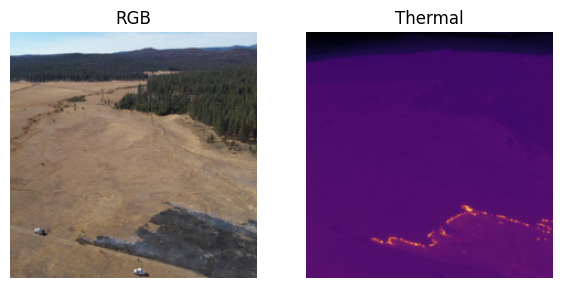

In [9]:
def build_llama3_tokens(user_text: str, assistant_text: Optional[str] = None):
    header_str = (
        '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n'
        'You are an expert wildfire intelligence system analyzing multimodal aerial imagery.<|eot_id|>'
        '<|start_header_id|>user<|end_header_id|>\n\n'
        'RGB Imagery Evidence: '
    )
    prompt_str = (
        f'\nThermal Imagery Evidence: \n{user_text}'
        '<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'
    )
    header_ids = tokenizer.encode(header_str, add_special_tokens=False)
    prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)

    target_ids = []
    if assistant_text is not None:
        eot_id = tokenizer.convert_tokens_to_ids('<|eot_id|>')
        answer_ids = tokenizer.encode(str(assistant_text), add_special_tokens=False)
        target_ids = answer_ids[:CFG.MAX_TARGET_TOKENS - 1] + [eot_id]
    return header_ids, prompt_ids, target_ids

@torch.no_grad()
def build_vision_feature_cache(paths, batch_size):
    cache = {}
    ordered_paths = sorted(set(str(p) for p in paths))
    model.vision_encoder.eval()
    started = time.perf_counter()

    for start in tqdm(range(0, len(ordered_paths), batch_size), desc='Caching frozen CLIP features'):
        chunk = ordered_paths[start:start + batch_size]
        images = [fast_load_and_resize(path) for path in chunk]
        pixels = image_processor(images=images, return_tensors='pt').pixel_values
        pixels = pixels.to(primary_device, dtype=torch.float16, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            patches = model.vision_encoder(pixel_values=pixels).last_hidden_state[:, 1:, :]
        patches = patches.to('cpu', dtype=torch.float16).contiguous()
        for path, feature in zip(chunk, patches):
            cache[path] = feature
        del images, pixels, patches

    elapsed = time.perf_counter() - started
    print(f'Cached {len(cache):,} unique images in {elapsed / 60:.2f} minutes.')
    return cache

all_image_paths = pd.concat([
    train_df['rgb_resolved'], train_df['thermal_resolved'],
    val_df['rgb_resolved'], val_df['thermal_resolved'],
    test_df['rgb_resolved'], test_df['thermal_resolved'],
]).dropna().astype(str).tolist()

VISION_FEATURE_CACHE = build_vision_feature_cache(
    all_image_paths,
    batch_size=CFG.VISION_CACHE_BATCH_SIZE,
)

# CLIP is no longer needed after caching, so release its GPU memory before training.
model.vision_encoder.to('cpu')
torch.cuda.empty_cache()

class WildfireTokenizedDataset(Dataset):
    def __init__(self, frame):
        self.records = []
        for row in frame.to_dict('records'):
            prompt = make_user_prompt(row)
            header_ids, prompt_ids, target_ids = build_llama3_tokens(prompt, str(row['answer']))
            self.records.append({
                'rgb_path': str(row['rgb_resolved']),
                'thermal_path': str(row['thermal_resolved']),
                'header_ids': header_ids,
                'prompt_ids': prompt_ids,
                'target_ids': target_ids,
                'question': str(row['question']),
                'target': str(row['answer']),
                'category': str(row.get('category', 'unknown')),
            })

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        return self.records[index]

def collate_fn(batch, is_eval: bool = False):
    return {
        'rgb_patches': torch.stack([VISION_FEATURE_CACHE[b['rgb_path']] for b in batch]),
        'thermal_patches': torch.stack([VISION_FEATURE_CACHE[b['thermal_path']] for b in batch]),
        'header_ids': [b['header_ids'] for b in batch],
        'prompt_ids': [b['prompt_ids'] for b in batch],
        'target_ids': [[] if is_eval else b['target_ids'] for b in batch],
        'rgb_paths': [b['rgb_path'] for b in batch],
        'thermal_paths': [b['thermal_path'] for b in batch],
        'questions': [b['question'] for b in batch],
        'targets': [b['target'] for b in batch],
        'categories': [b['category'] for b in batch],
    }

train_dataset = WildfireTokenizedDataset(train_df)
val_dataset = WildfireTokenizedDataset(val_df)
test_dataset = WildfireTokenizedDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=lambda batch: collate_fn(batch, is_eval=False),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=lambda batch: collate_fn(batch, is_eval=False),
)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
_b = next(iter(val_loader))
_diff = (_b['rgb_patches'] - _b['thermal_patches']).abs().mean().item()
print(f'Mean |RGB - thermal| CLIP feature difference: {_diff:.4f}')
assert _diff > 1e-4, 'RGB and thermal features look identical; check path resolution.'

fig, ax = plt.subplots(1, 2, figsize=(7, 3.2))
ax[0].imshow(fast_load_and_resize(_b['rgb_paths'][0])); ax[0].set_title('RGB'); ax[0].axis('off')
ax[1].imshow(fast_load_and_resize(_b['thermal_paths'][0])); ax[1].set_title('Thermal'); ax[1].axis('off')
plt.show()


In [10]:
def assemble_batch_embeddings(model: WildfireQLoRAVLM, batch_data: dict, compute_labels: bool = True):
    rgb_patches = batch_data['rgb_patches'].to(primary_device, non_blocking=True)
    thermal_patches = batch_data['thermal_patches'].to(primary_device, non_blocking=True)

    rgb_embeds = model.project_visual_patches(rgb_patches, model.rgb_projector, model.rgb_type)
    thermal_embeds = model.project_visual_patches(
        thermal_patches, model.thermal_projector, model.thermal_type
    )
    batch_size = rgb_embeds.size(0)

    embed_layer = model.llm.get_input_embeddings()
    embedding_device = embed_layer.weight.device
    embedding_dtype = embed_layer.weight.dtype
    rgb_embeds = rgb_embeds.to(embedding_device, dtype=embedding_dtype)
    thermal_embeds = thermal_embeds.to(embedding_device, dtype=embedding_dtype)

    sequence_embeddings = []
    sequence_labels = []

    for index in range(batch_size):
        header_ids = torch.as_tensor(
            batch_data['header_ids'][index], dtype=torch.long, device=embedding_device
        )
        prompt_ids = torch.as_tensor(
            batch_data['prompt_ids'][index], dtype=torch.long, device=embedding_device
        )
        target_ids = torch.as_tensor(
            batch_data['target_ids'][index], dtype=torch.long, device=embedding_device
        ) if compute_labels else None

        header_embeddings = embed_layer(header_ids)
        prompt_embeddings = embed_layer(prompt_ids)
        parts = [
            header_embeddings,
            rgb_embeds[index],
            thermal_embeds[index],
            prompt_embeddings,
        ]
        if compute_labels and target_ids is not None and target_ids.numel() > 0:
            parts.append(embed_layer(target_ids))

        full_embeddings = torch.cat(parts, dim=0)
        sequence_embeddings.append(full_embeddings)

        if compute_labels:
            non_target_length = sum(part.size(0) for part in parts[:-1])
            target_length = target_ids.numel() if target_ids is not None else 0
            labels = torch.full(
                (non_target_length + target_length,),
                -100,
                dtype=torch.long,
                device=embedding_device,
            )
            if target_length:
                labels[non_target_length:] = target_ids
            sequence_labels.append(labels)

    max_length = max(embeddings.size(0) for embeddings in sequence_embeddings)
    padded_embeddings = torch.zeros(
        batch_size,
        max_length,
        model.llm_dim,
        dtype=embedding_dtype,
        device=embedding_device,
    )
    attention_mask = torch.zeros(
        batch_size, max_length, dtype=torch.long, device=embedding_device
    )
    padded_labels = torch.full(
        (batch_size, max_length), -100, dtype=torch.long, device=embedding_device
    ) if compute_labels else None

    for index, embeddings in enumerate(sequence_embeddings):
        sequence_length = embeddings.size(0)
        if compute_labels:
            padded_embeddings[index, :sequence_length] = embeddings
            attention_mask[index, :sequence_length] = 1
            padded_labels[index, :sequence_length] = sequence_labels[index]
        else:
            padded_embeddings[index, -sequence_length:] = embeddings
            attention_mask[index, -sequence_length:] = 1

    return padded_embeddings, attention_mask, padded_labels


In [11]:
def simple_tokens(s: str) -> List[str]:
    return re.findall(r"\w+|[^\w\s]", str(s).lower())

def ngram_counts(tokens: List[str], n: int) -> Counter:
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def sentence_bleu(reference: str, prediction: str, max_n: int = 4) -> float:
    ref = simple_tokens(reference)
    pred = simple_tokens(prediction)
    if not pred:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        pred_counts = ngram_counts(pred, n)
        ref_counts = ngram_counts(ref, n)
        if not pred_counts:
            precisions.append(1e-9)
            continue
        overlap = sum(min(c, ref_counts[g]) for g, c in pred_counts.items())
        precisions.append((overlap + 1) / (sum(pred_counts.values()) + 1))
    bp = 1.0 if len(pred) > len(ref) else math.exp(1 - len(ref) / max(len(pred), 1))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n)

def lcs_len(a: List[str], b: List[str]) -> int:
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            cur = dp[j]
            if x == y:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j-1])
            prev = cur
    return dp[-1]

def rouge_l(reference: str, prediction: str) -> float:
    ref = simple_tokens(reference)
    pred = simple_tokens(prediction)
    if not ref or not pred:
        return 0.0
    lcs = lcs_len(ref, pred)
    prec = lcs / len(pred)
    rec = lcs / len(ref)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def exact_match(reference: str, prediction: str) -> int:
    return int(str(reference).strip().lower() == str(prediction).strip().lower())


In [12]:
trainable_params = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY,
)

steps_per_epoch = math.ceil(len(train_loader) / CFG.GRAD_ACCUM_STEPS)
total_steps = CFG.EPOCHS * steps_per_epoch
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * CFG.WARMUP_RATIO),
    num_training_steps=total_steps,
)

best_val_loss = float('inf')
epochs_without_improvement = 0
history = []
model.llm.config.use_cache = False

for epoch in range(1, CFG.EPOCHS + 1):
    epoch_started = time.perf_counter()
    model.train()
    running_loss = 0.0
    pending_loss = None
    seen_samples = 0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{CFG.EPOCHS}', mininterval=1.0)
    for step, batch in enumerate(pbar, 1):
        inputs_embeds, attention_mask, labels = assemble_batch_embeddings(
            model, batch, compute_labels=True
        )

        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss / CFG.GRAD_ACCUM_STEPS

        loss.backward()

        if step % CFG.GRAD_ACCUM_STEPS == 0 or step == len(train_loader):
            torch.nn.utils.clip_grad_norm_(trainable_params, CFG.GRAD_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        batch_size = inputs_embeds.size(0)
        weighted_loss = loss.detach().float() * CFG.GRAD_ACCUM_STEPS * batch_size
        pending_loss = weighted_loss if pending_loss is None else pending_loss + weighted_loss
        seen_samples += batch_size

        if step % CFG.LOG_EVERY == 0 or step == len(train_loader):
            running_loss += pending_loss.item()
            pending_loss = None
            pbar.set_postfix(train_loss=f'{running_loss / seen_samples:.4f}')

    model.eval()
    val_loss_tensor = None
    val_samples = 0
    with torch.inference_mode():
        for batch in tqdm(val_loader, desc='Validating', leave=False, mininterval=1.0):
            inputs_embeds, attention_mask, labels = assemble_batch_embeddings(
                model, batch, compute_labels=True
            )
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(
                    inputs_embeds=inputs_embeds,
                    attention_mask=attention_mask,
                    labels=labels,
                )
            batch_size = inputs_embeds.size(0)
            weighted_loss = outputs.loss.detach().float() * batch_size
            val_loss_tensor = weighted_loss if val_loss_tensor is None else val_loss_tensor + weighted_loss
            val_samples += batch_size

    val_loss = val_loss_tensor.item() / max(val_samples, 1)
    train_loss_epoch = running_loss / max(seen_samples, 1)
    elapsed_minutes = (time.perf_counter() - epoch_started) / 60
    record = {
        'epoch': epoch,
        'train_loss': train_loss_epoch,
        'val_loss': val_loss,
        'minutes': elapsed_minutes,
    }
    history.append(record)
    print(f'Epoch {epoch} Results:', record)

    improved = val_loss < (best_val_loss - CFG.EARLY_STOPPING_MIN_DELTA)
    if improved:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save({
            'rgb_projector': model.rgb_projector.state_dict(),
            'thermal_projector': model.thermal_projector.state_dict(),
            'rgb_type': model.rgb_type.detach().cpu(),
            'thermal_type': model.thermal_type.detach().cpu(),
        }, CFG.OUTPUT_DIR / 'best_projectors.pt')
        model.llm.save_pretrained(CFG.OUTPUT_DIR / 'best_lora_adapters')
        tokenizer.save_pretrained(CFG.OUTPUT_DIR / 'tokenizer')
        print('--> Saved new best projectors + LoRA adapters!')
    else:
        epochs_without_improvement += 1
        print(
            f'Validation loss did not improve by at least '
            f'{CFG.EARLY_STOPPING_MIN_DELTA:g}. '
            f'Patience: {epochs_without_improvement}/'
            f'{CFG.EARLY_STOPPING_PATIENCE}'
        )
        if epochs_without_improvement >= CFG.EARLY_STOPPING_PATIENCE:
            print(f'Early stopping after epoch {epoch}.')
            break

pd.DataFrame(history).to_csv(CFG.OUTPUT_DIR / 'training_history.csv', index=False)


Epoch 1/8:   0%|          | 0/5024 [00:00<?, ?it/s]

Validating:   0%|          | 0/612 [00:00<?, ?it/s]

Epoch 1 Results: {'epoch': 1, 'train_loss': 0.6041253075571669, 'val_loss': 0.22314343421287786, 'minutes': 31.674808432483335}
--> Saved new best projectors + LoRA adapters!


Epoch 2/8:   0%|          | 0/5024 [00:00<?, ?it/s]

Validating:   0%|          | 0/612 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/612 [00:00<?, ?it/s]

Epoch 4 Results: {'epoch': 4, 'train_loss': 0.2102840541191477, 'val_loss': 0.2000358556610307, 'minutes': 31.217991558433322}
Validation loss did not improve by at least 0.001. Patience: 1/2


Epoch 5/8:   0%|          | 0/5024 [00:00<?, ?it/s]

Validating:   0%|          | 0/612 [00:00<?, ?it/s]

Epoch 5 Results: {'epoch': 5, 'train_loss': 0.2061458447447722, 'val_loss': 0.20183982101141237, 'minutes': 31.188912163233333}
Validation loss did not improve by at least 0.001. Patience: 2/2
Early stopping after epoch 5.


Loaded best projectors from: /kaggle/working/firevlm_lora_balanced_qkvo_r16/best_projectors.pt
Loaded best LoRA adapters from: /kaggle/working/firevlm_lora_balanced_qkvo_r16/best_lora_adapters


Generating answers:   0%|          | 0/638 [00:00<?, ?it/s]


                HELD-OUT TEST METRICS (QLoRA)
Total Samples Evaluated: 2550
Exact Match (EM):        69.14%
BLEU-4 Score:            0.1091
ROUGE-L Score:           0.7621

             PERFORMANCE BY QUESTION CATEGORY


,Exact Match (%),BLEU-4,ROUGE-L
category,,,
Presence and Detection,78.833333,7.965324e-07,0.821667
Flight Planning,73.666667,4.518316e-01,0.833000
Cross-Modal Reasoning,71.666667,4.755029e-04,0.812333
Distribution and Segmentation,66.666667,2.343552e-01,0.762857
Classification,62.000000,2.322167e-03,0.688000
Localization and Direction,58.333333,2.467786e-03,0.631111



         SAMPLE PREDICTIONS WITH DUAL IMAGERY


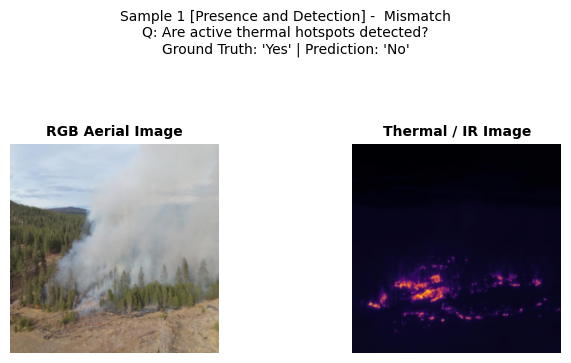

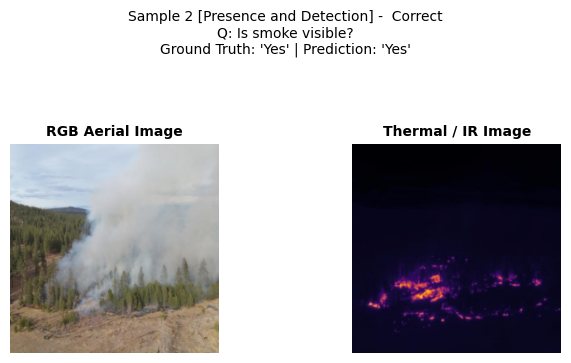

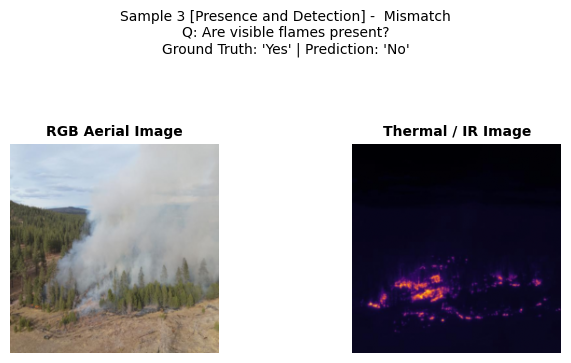

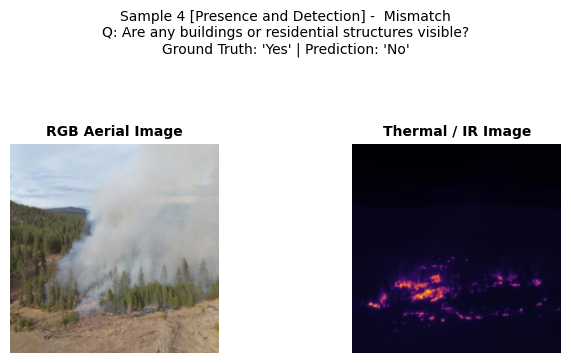

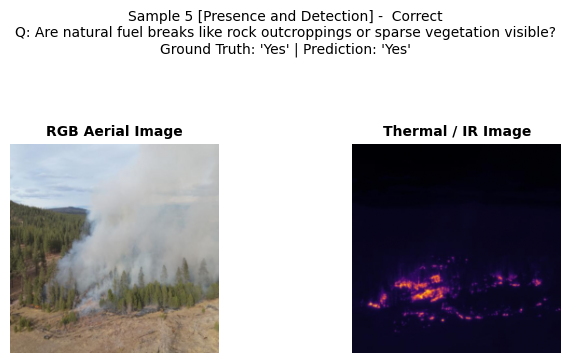

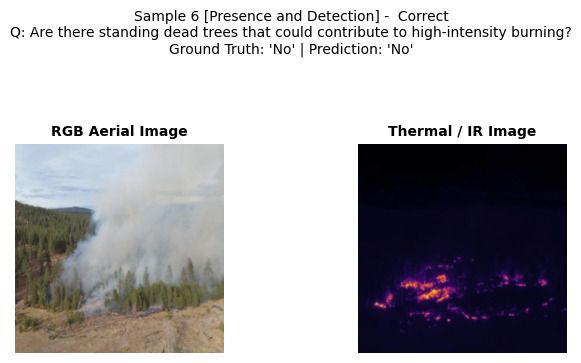

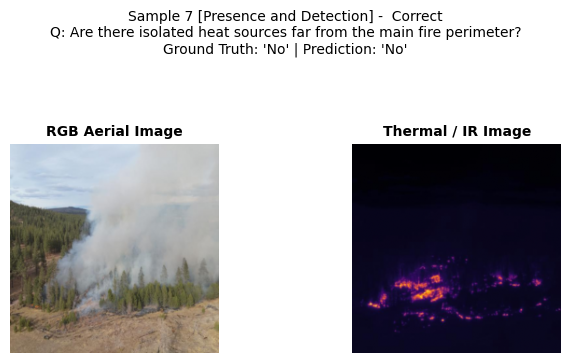

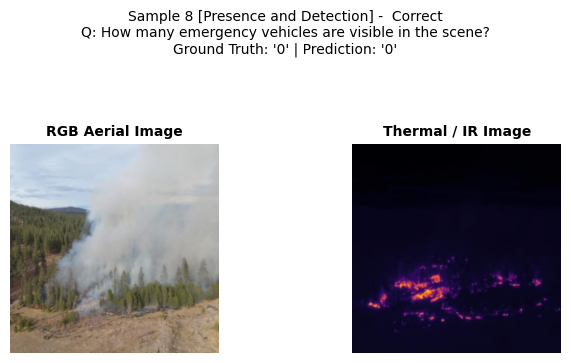

In [13]:
best_proj_path = CFG.OUTPUT_DIR / 'best_projectors.pt'
best_lora_path = CFG.OUTPUT_DIR / 'best_lora_adapters'
primary_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if best_proj_path.exists():
    state = torch.load(best_proj_path, map_location=primary_device)
    model.rgb_projector.load_state_dict(state['rgb_projector'])
    model.thermal_projector.load_state_dict(state['thermal_projector'])
    model.rgb_type.data.copy_(state['rgb_type'].to(primary_device))
    model.thermal_type.data.copy_(state['thermal_type'].to(primary_device))
    print(f"Loaded best projectors from: {best_proj_path}")

if best_lora_path.exists():
    # Actually load the best adapter weights (the old code only printed a message)
    model.llm.load_adapter(str(best_lora_path), adapter_name='best', is_trainable=False)
    model.llm.set_adapter('best')
    print(f"Loaded best LoRA adapters from: {best_lora_path}")

model.eval()
model.llm.config.use_cache = True

# 2. Evaluation DataLoader (is_eval=True -> No ground-truth answer in prompt)
test_eval_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=lambda b: collate_fn(b, is_eval=True),
)

pred_rows = []
sample_visualizations = []  # Stores sample images + predictions for plotting

# 3. Autoregressive Generation Loop
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_eval_loader, desc="Generating answers")):
        inputs_embeds, attention_mask, _ = assemble_batch_embeddings(
            model, batch, compute_labels=False
        )

        with torch.amp.autocast("cuda", dtype=torch.float16):
            gen_output = model.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                max_new_tokens=CFG.MAX_GENERATE_TOKENS,
                num_beams=1,
                do_sample=False,
            )

        preds = tokenizer.batch_decode(gen_output, skip_special_tokens=True, clean_up_tokenization_spaces=False)

        for i, (q, target, raw_pred, cat) in enumerate(zip(
            batch["questions"], batch["targets"], preds, batch["categories"]
        )):
            clean_pred = raw_pred.strip().split("\n")[0].strip()
            clean_pred = re.sub(r'[\r\t]', '', clean_pred)

            em = exact_match(target, clean_pred)
            bleu = sentence_bleu(target, clean_pred)
            r_l = rouge_l(target, clean_pred)

            record = {
                "category": cat,
                "question": q,
                "target": target,
                "prediction": clean_pred,
                "exact_match": em,
                "bleu": bleu,
                "rouge_l": r_l,
            }
            pred_rows.append(record)

            # Collect the first 8 samples for visual display
            if len(sample_visualizations) < 8:
                rgb_img = np.asarray(fast_load_and_resize(batch["rgb_paths"][i])) / 255.0
                th_img = np.asarray(fast_load_and_resize(batch["thermal_paths"][i])) / 255.0

                sample_visualizations.append({
                    "rgb": rgb_img,
                    "thermal": th_img,
                    "question": q,
                    "target": target,
                    "prediction": clean_pred,
                    "category": cat,
                    "em": em,
                })

# 4. Save Predictions & Summary
pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(CFG.OUTPUT_DIR / "test_predictions.csv", index=False)

summary = {
    "exact_match": float(pred_df["exact_match"].mean()) if len(pred_df) else 0.0,
    "bleu": float(pred_df["bleu"].mean()) if len(pred_df) else 0.0,
    "rouge_l": float(pred_df["rouge_l"].mean()) if len(pred_df) else 0.0,
    "n_samples": int(len(pred_df)),
}

with open(CFG.OUTPUT_DIR / "test_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("                HELD-OUT TEST METRICS (QLoRA)")
print("="*60)
print(f"Total Samples Evaluated: {summary['n_samples']}")
print(f"Exact Match (EM):        {summary['exact_match'] * 100:.2f}%")
print(f"BLEU-4 Score:            {summary['bleu']:.4f}")
print(f"ROUGE-L Score:           {summary['rouge_l']:.4f}")

print("\n" + "="*60)
print("             PERFORMANCE BY QUESTION CATEGORY")
print("="*60)
category_df = (
    pred_df.groupby("category")[["exact_match", "bleu", "rouge_l"]]
    .mean()
    .sort_values("exact_match", ascending=False)
)
category_df["exact_match"] = category_df["exact_match"] * 100
category_df.columns = ["Exact Match (%)", "BLEU-4", "ROUGE-L"]
display(category_df)

# ---------------------------------------------------------
# 5. Visual Sample Inspection (RGB + Thermal Pairs)
# ---------------------------------------------------------
print("\n" + "="*60)
print("         SAMPLE PREDICTIONS WITH DUAL IMAGERY")
print("="*60)

for idx, item in enumerate(sample_visualizations):
    same = np.allclose(item["rgb"], item["thermal"], atol=1e-3)
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

    axes[0].imshow(item["rgb"])
    axes[0].set_title("RGB Aerial Image", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(item["thermal"])
    axes[1].set_title("Thermal / IR Image", fontsize=10, fontweight="bold")
    axes[1].axis("off")

    status_icon = " Correct" if item["em"] == 1 else " Mismatch"
    warn = "  [WARNING: RGB == thermal]" if same else ""
    plt.suptitle(
        f"Sample {idx+1} [{item['category']}] - {status_icon}{warn}\n"
        f"Q: {item['question']}\n"
        f"Ground Truth: '{item['target']}' | Prediction: '{item['prediction']}'",
        fontsize=10,
        y=1.12,
        ha="center"
    )
    plt.tight_layout()
    plt.show()


In [14]:
!zip -r /kaggle/working/firevlm_lora_balanced_qkvo_r16.zip /kaggle/working/firevlm_lora_balanced_qkvo_r16


  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/ (stored 0%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/test_predictions.csv (deflated 98%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/tokenizer/ (stored 0%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/tokenizer/tokenizer_config.json (deflated 44%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/tokenizer/chat_template.jinja (deflated 71%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/tokenizer/tokenizer.json (deflated 85%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/test_metrics.json (deflated 18%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/best_projectors.pt (deflated 8%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/training_history.csv (deflated 41%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/best_lora_adapters/ (stored 0%)
  adding: kaggle/working/firevlm_lora_balanced_qkvo_r16/best_lora_adapters/README.md (deflated 65%)
  